In [1]:
# %load_ext autoreload
# %autoreload 2
from easy_arts import scat_data
from physics.constants import SPEED_OF_LIGHT
from earthcare_ir import PSD, Habit

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import data_paths as dp


# IR

In [2]:
# Yang General Habit Mixture from Robin Shannon
path = './data/scat_data_robin_shannon/'
ds_scat_mix = xr.open_dataset(path + 'ice-yang-general-habit-mixture-003_10800-nm_scat.nc')
ds_scat_mix = ds_scat_mix.set_coords(['wavelength', 'temperature', 'mean_dimension', 'maximum_dimension', 'area', 'mass'])
ds_scat_mix = ds_scat_mix.eval('ssa = scat / ext')
ds_scat_mix

<xarray.Dataset> Size: 7kB
Dimensions:            (size: 189)
Coordinates:
    wavelength         float32 4B ...
    temperature        float32 4B ...
    mean_dimension     (size) float32 756B ...
    maximum_dimension  (size) float32 756B ...
    area               (size) float32 756B ...
    mass               (size) float32 756B ...
Dimensions without coordinates: size
Data variables:
    ext                (size) float32 756B ...
    scat               (size) float32 756B ...
    g                  (size) float32 756B ...
    bscat              (size) float32 756B ...
    ssa                (size) float32 756B 0.01255 0.03637 ... 0.5345 0.5344
Attributes:
    title:      Ping Yang's ice particle scattering properties for the genera...
    source:     Data_0.2_15.25/single_column/Rough003/isca.dat\nData_0.2_15.2...
    reference:  Yang, P., L. Bi, B. A. Baum, K.-N. Liou, G. W. Kattawar, M. I...
    habit:      single_column plate HC droxtal HBR SBR 8_columns 5_plates 10_...
    roughness:  3
    history:    03-Feb-2025: converted to netCDF from ASCII\n03-Feb-2025: mer...

In [3]:
from physics.constants import SPEED_OF_LIGHT

ds_scat_ping = scat_data.import2xarray(
    '/scratch/li/arts-yang-liquid-simlink',
    habit='Plate-ModeratelyRough', 
    interpolate_na=False,
)
ds_scat_ping = ds_scat_ping.interp(f_grid=SPEED_OF_LIGHT / 10.8e-6 )
ds_scat_ping = scat_data.add_backscattering(ds_scat_ping)
ds_scat_ping = scat_data.add_single_scattering_albedo(ds_scat_ping)
ds_scat_ping = scat_data.add_asymmetry_parameter(ds_scat_ping)

In [4]:
ds_scat_ping

<xarray.Dataset> Size: 5MB
Dimensions:                   (T_grid: 1, size: 189, za_sca_grid: 498,
                               za_inc_grid: 1, aa_inc_grid: 1,
                               ext_mat_element: 1, abs_vec_element: 1,
                               aa_sca_grid: 1, pha_mat_element: 6)
Coordinates:
  * T_grid                    (T_grid) float64 8B 266.0
    d_veq                     (size) float64 2kB 2.149e-06 ... 0.002596
    d_max                     (size) float64 2kB 2e-06 3e-06 ... 0.009875 0.01
    mass                      (size) float64 2kB 4.763e-15 ... 8.396e-06
    d_area                    float64 8B nan
  * za_sca_grid               (za_sca_grid) float64 4kB 0.0 0.01 ... 179.8 180.0
    f_grid                    float64 8B 2.776e+13
Dimensions without coordinates: size, za_inc_grid, aa_inc_grid,
                                ext_mat_element, abs_vec_element, aa_sca_grid,
                                pha_mat_element
Data variables:
    ext_mat_data              (size, T_grid, za_inc_grid, aa_inc_grid, ext_mat_element) float64 2kB ...
    abs_vec_data              (size, T_grid, za_inc_grid, aa_inc_grid, abs_vec_element) float64 2kB ...
    pha_mat_data              (size, T_grid, za_sca_grid, aa_sca_grid, za_inc_grid, aa_inc_grid, pha_mat_element) float64 5MB ...
    backscattering            (size, T_grid, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 2kB ...
    single_scattering_albedo  (size, T_grid, za_inc_grid, aa_inc_grid) float64 2kB ...
    asymmetry_parameter       (size, T_grid, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 2kB ...
Attributes:
    description:  Plate, following P. Yang (2013) and Bi, L., and P. Yang (20...
    ptype:        PType.PTYPE_TOTAL_RND

In [10]:
ds_scat_ping_2 = scat_data.import2xarray(
    '/scratch/li/arts-yang-liquid-simlink',
    habit='8-ColumnAggregate-ModeratelyRough', 
    interpolate_na=False,
)
ds_scat_ping_2 = ds_scat_ping_2.interp(f_grid=SPEED_OF_LIGHT / 10.8e-6 )
ds_scat_ping_2 = scat_data.add_backscattering(ds_scat_ping_2)
ds_scat_ping_2 = scat_data.add_single_scattering_albedo(ds_scat_ping_2)
ds_scat_ping_2 = scat_data.add_asymmetry_parameter(ds_scat_ping_2)

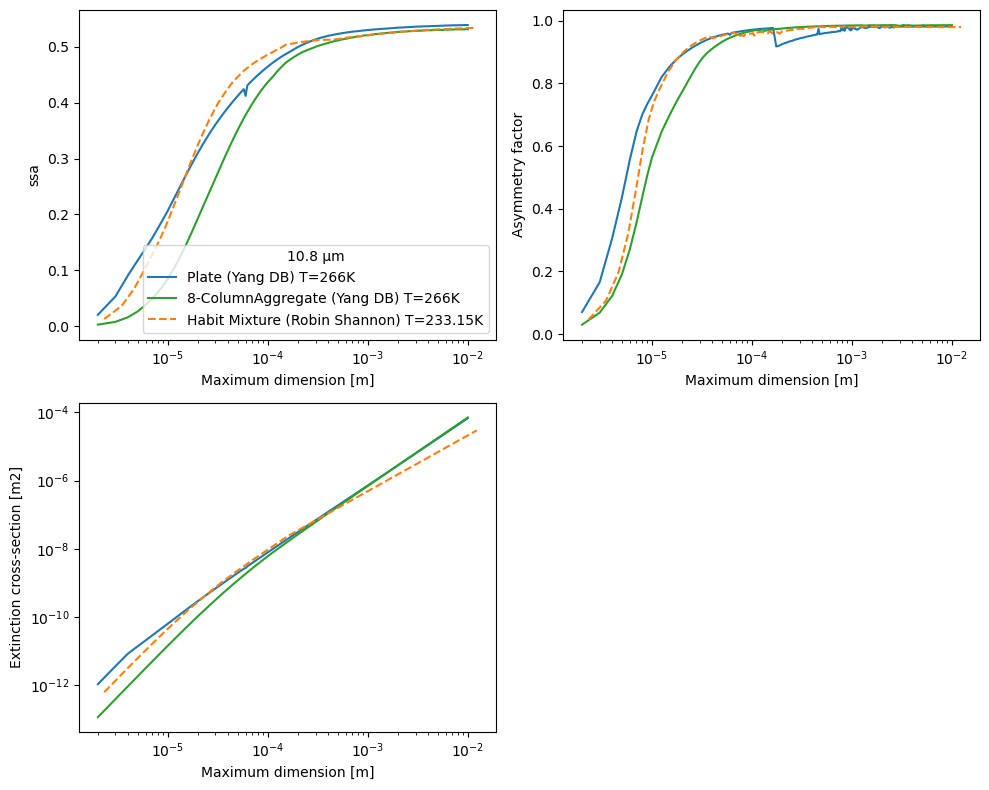

In [130]:
fig, ax = plt.subplots(2,2, figsize=(10,8), squeeze=False)
x1 = 'd_max'
x2 = 'maximum_dimension'
label1 = 'Plate (Yang DB) T=266K'
label2 = 'Habit Mixture (Robin Shannon) T=233.15K'
label3 = '8-ColumnAggregate (Yang DB) T=266K'

ds_scat_ping.single_scattering_albedo.plot(x=x1, ax=ax[0,0], label=label1)
ds_scat_ping_2.single_scattering_albedo.plot(x=x1, ax=ax[0,0], label=label3, linestyle='-', color='C2')
ds_scat_mix.ssa.plot(x=x2, ax=ax[0,0], label=label2, linestyle='--', color='C1')

ds_scat_ping.asymmetry_parameter.plot(x=x1, ax=ax[0,1], label=label1)
ds_scat_ping_2.asymmetry_parameter.plot(x=x1, ax=ax[0,1], label=label3, linestyle='-', color='C2')
ds_scat_mix.g.plot(x=x2, ax=ax[0,1], label=label2, linestyle='--', color='C1')

ds_scat_ping.ext_mat_data.plot(x=x1, ax=ax[1,0], label=label1)
ds_scat_ping_2.ext_mat_data.plot(x=x1, ax=ax[1,0], label=label3, color='C2')
ds_scat_mix.ext.plot(x=x2, ax=ax[1,0], label=label2, linestyle='--', color='C1')

for i, axs in enumerate(ax.flatten()):
    axs.set_xscale('log')
    axs.set_yscale('log')
    axs.set_title('')
    if i==0 or i==1:
        axs.set_yscale('linear')

ax[0,0].legend(title=f'10.8 µm')
ax[1,1].axis('off')
fig.tight_layout()

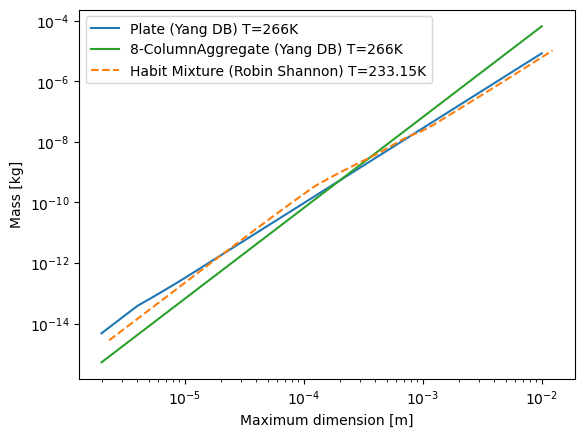

In [ ]:
# Mass-size relation
plt.figure(figsize=(6,4))
ds_scat_ping.mass.plot(x='d_max', label=label1)
ds_scat_ping_2.mass.plot(x='d_max', color='C2', linestyle='-', label=label3)
ds_scat_mix.mass.plot(x='maximum_dimension', color='C1', linestyle='--', label=label2)
plt.xscale('log')
plt.yscale('log')
plt.title('')
plt.legend()

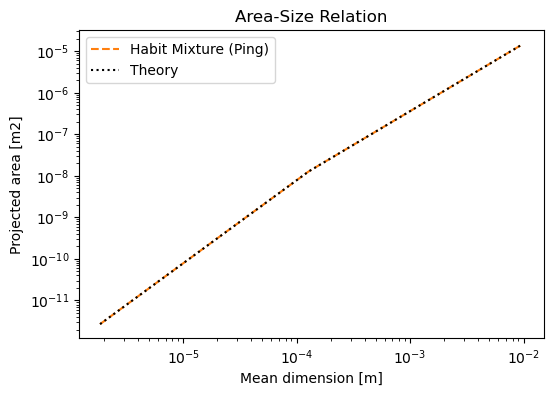

In [3]:
# Area-size relation
def area_size_relation(D):
    ice_area = np.minimum(D**2 * np.pi / 4, 0.02683 * D**1.624)
    return ice_area
plt.figure(figsize=(6,4))
ds_scat_mix.area.plot(x='mean_dimension', color='C1', linestyle='--', label='Habit Mixture (Ping)')
D_vals = ds_scat_mix.mean_dimension.values
plt.plot(D_vals, area_size_relation(D_vals), color='k', linestyle=':', label='Theory')
plt.xscale('log')
plt.yscale('log')
plt.title('Area-Size Relation')
plt.legend()

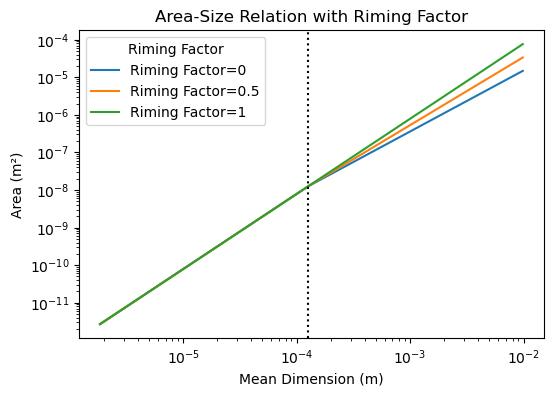

In [27]:
def area_size_relation(D, riming_facor):
    r_max = 1
    b = 2 * riming_facor/r_max + 1.624 * (1 - riming_facor/r_max)
    pivot_D = (0.02683 / (np.pi/4)) ** (1.0 / (2-1.624)) 
    # pivot_D = 61e-6 m
    pivot_A = 0.02683 * pivot_D**1.624
    a = pivot_A / (pivot_D**b)
    ice_area = np.minimum(np.pi/4 * D**2, a * D**b)
    return ice_area

def are_ratio(D, riming_factor):
    r_max = 1 
    b = 2 * riming_factor/r_max + 1.624 * (1 - riming_factor/r_max)
    pivot_D = (0.02683 / (np.pi/4)) ** (1.0 / (2-1.624))
    return np.where(
        D <= pivot_D,
        1.0,
        (D/pivot_D)**(b - 2)
    )
D = ds_scat_mix.mean_dimension.values
plt.figure(figsize=(6,4))
for riming_factor in [0, 0.5, 1]:
    plt.plot(D, area_size_relation(D, riming_factor), label=f'Riming Factor={riming_factor}')
plt.xscale('log')
plt.yscale('log')
plt.legend(title='Riming Factor')
plt.axvline(x=(0.02683 / (np.pi/4)) ** (1.0 / (2-1.624)) , color='k', linestyle=':')
plt.title('Area-Size Relation with Riming Factor')
plt.xlabel('Mean Dimension (m)')
plt.ylabel('Area (m²)')
plt.show()


In [41]:
import pandas as pd
import xarray as xr

df = pd.read_csv('./data/peter/particle_size_summary.csv')
df['area_um2'] = df['area_um2'] * 1e-12
df['d_size_um'] = df['d_size_um'] * 1e-6
ds = xr.Dataset.from_dataframe(df)
df

,particle_type,particle_id,dveq_um,n_points,d_size_um,area_um2
0,HexColAggCrystal-Dmax100um-AxisRatio1.25,21,72,1204,0.000268,4.704474e-08
1,HexColAggCrystal-Dmax100um-AxisRatio1.25,21,131,1061,0.000338,6.025296e-08
2,HexColAggCrystal-Dmax100um-AxisRatio1.25,21,191,1176,0.000395,7.855724e-08
3,HexColAggCrystal-Dmax100um-AxisRatio1.25,21,247,2524,0.000571,1.583243e-07
4,HexColAggCrystal-Dmax100um-AxisRatio1.25,21,322,5404,0.000775,2.762309e-07
...,...,...,...,...,...,...
263,LiuThinPlate,16,1241,315348,0.002716,4.804895e-06
264,LiuThinPlate,16,1398,182781,0.002283,3.397350e-06
265,LiuThinPlate,16,1576,262340,0.002592,4.377504e-06
266,LiuThinPlate,16,1775,118696,0.001959,2.493218e-06


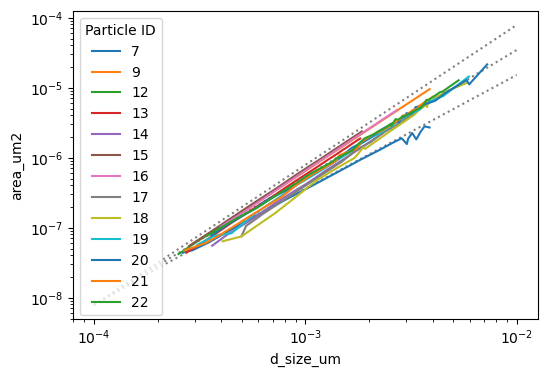

In [45]:
plt.figure(figsize=(6,4))

D = np.linspace(1e-4, 1e-2, 100)
for riming_factor in [0, 0.5, 1]:
    plt.plot(D, area_size_relation(D, riming_factor), c='grey', ls=':')


for particle_id in ds.particle_id.pipe(np.unique):
    ds.groupby('particle_id')[particle_id].sortby('d_size_um').set_coords('d_size_um')['area_um2'].plot(x='d_size_um', label=f'{particle_id}')

plt.legend(title='Particle ID')
plt.xscale('log')
plt.yscale('log')

# Microwave

In [5]:
#SSRGA
path = './data/scat_data_robin_shannon/'
ds_scat_ssrga = xr.open_dataset(path + 'ice-self-similar-aggregates_94-GHz_scat.nc')
ds_scat_ssrga = ds_scat_ssrga.set_coords(['wavelength', 'mean_dimension', 'maximum_dimension', 'area', 'mass'])
ds_scat_ssrga

<xarray.Dataset> Size: 222kB
Dimensions:            (temperature: 5, fraction: 25, size: 100)
Coordinates:
    wavelength         float32 4B ...
  * temperature        (temperature) float32 20B 193.1 213.1 233.1 253.1 273.1
  * fraction           (fraction) float32 100B 0.01 0.01212 ... 0.8254 1.0
    mean_dimension     (size) float32 400B ...
    maximum_dimension  (size) float32 400B ...
    area               (size) float32 400B ...
    mass               (fraction, size) float32 10kB ...
Dimensions without coordinates: size
Data variables:
    fall_speed         (fraction, size) float32 10kB ...
    n_r                (temperature, fraction) float32 500B ...
    n_i                (temperature, fraction) float32 500B ...
    ext                (temperature, fraction, size) float32 50kB ...
    scat               (temperature, fraction, size) float32 50kB ...
    bscat              (temperature, fraction, size) float32 50kB ...
    g                  (temperature, fraction, size) float32 50kB ...
Attributes:
    title:         Scattering properties of ice particles computed using the ...
    history:       Wed Dec 17 09:38:01 2025 - Computed particle scattering pr...
    command_line:  ../../src/scatter/scatter show_dots=1 ../scattering_input/...
    config:        wavelength 0.0031893\narea_diameter_prefactor 0.02683\nare...

In [6]:
habit = 'IconHail'
ds_scat_arts = scat_data.import2xarray(
    # '/scratch/patrick/Data/StandardHabits',
    # '/data/s5/users/patrick/IconHail',
    '/data/s5/scattering_data/ArtsScatDbase/ArtsScatDbase_v1.0.0/StandardHabits/FullSet/',
    habit=habit, 
    interpolate_na=False,
).interp(f_grid=94e9)
ds_scat_arts = scat_data.add_backscattering(ds_scat_arts)
ds_scat_arts = scat_data.add_single_scattering_albedo(ds_scat_arts)
ds_scat_arts = scat_data.add_asymmetry_parameter(ds_scat_arts)
ds_scat_arts

<xarray.Dataset> Size: 7MB
Dimensions:                   (T_grid: 5, size: 42, za_sca_grid: 721,
                               za_inc_grid: 1, aa_inc_grid: 1,
                               ext_mat_element: 1, abs_vec_element: 1,
                               aa_sca_grid: 1, pha_mat_element: 6)
Coordinates:
  * T_grid                    (T_grid) float64 40B 190.0 210.0 230.0 250.0 270.0
    d_veq                     (size) float64 336B 1e-05 2e-05 ... 0.004457 0.005
    d_max                     (size) float64 336B 1.029e-05 ... 0.005349
    mass                      (size) float64 336B 4.8e-13 3.84e-12 ... 6e-05
    d_area                    (size) float64 336B 1.029e-05 ... 0.005349
  * za_sca_grid               (za_sca_grid) float64 6kB 0.0 0.25 ... 179.8 180.0
    f_grid                    float64 8B 9.4e+10
Dimensions without coordinates: size, za_inc_grid, aa_inc_grid,
                                ext_mat_element, abs_vec_element, aa_sca_grid,
                                pha_mat_element
Data variables:
    ext_mat_data              (size, T_grid, za_inc_grid, aa_inc_grid, ext_mat_element) float64 2kB ...
    abs_vec_data              (size, T_grid, za_inc_grid, aa_inc_grid, abs_vec_element) float64 2kB ...
    pha_mat_data              (size, T_grid, za_sca_grid, aa_sca_grid, za_inc_grid, aa_inc_grid, pha_mat_element) float64 7MB ...
    backscattering            (size, T_grid, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 2kB ...
    single_scattering_albedo  (size, T_grid, za_inc_grid, aa_inc_grid) float64 2kB ...
    asymmetry_parameter       (size, T_grid, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 2kB ...
Attributes:
    description:  GEM cloud ice
    ptype:        PType.PTYPE_TOTAL_RND

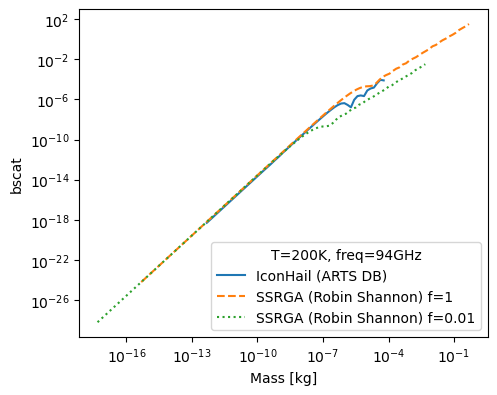

In [7]:
T = 200  # K
f = 1 # ice fraction / rimming factor
f2 = 0.01

fig, ax = plt.subplots(2,2, figsize=(10,8))
x1 = 'mass'
x2 = 'mass'

label1 = f'{habit} (ARTS DB)'
label2 = f'SSRGA (Robin Shannon) f={f}'
label3 = f'SSRGA (Robin Shannon) f={f2}'

ds_scat_arts.interp(T_grid=T).single_scattering_albedo.plot(x=x1, ax=ax[0,0], label=label1)
ds_scat_ssrga.interp(temperature=T, fraction=f).eval('ssa = scat / ext').ssa.plot(x=x2, ax=ax[0,0], label=label2, linestyle='--')
ds_scat_ssrga.interp(temperature=T, fraction=f2).eval('ssa = scat / ext').ssa.plot(x=x2, ax=ax[0,0], label=label3, linestyle=':')

ds_scat_arts.interp(T_grid=T).asymmetry_parameter.plot(x=x1, ax=ax[0,1], label=label1)
ds_scat_ssrga.interp(temperature=T, fraction=f).g.plot(x=x2, ax=ax[0,1], label=label2, linestyle='--')
ds_scat_ssrga.interp(temperature=T, fraction=f2).g.plot(x=x2, ax=ax[0,1], label=label3, linestyle=':')
ds_scat_arts.interp(T_grid=T).ext_mat_data.plot(x=x1, ax=ax[1,0], label=label1)
ds_scat_ssrga.interp(temperature=T, fraction=f).ext.plot(x=x2, ax=ax[1,0], label=label2, linestyle='--')
ds_scat_ssrga.interp(temperature=T, fraction=f2).ext.plot(x=x2, ax=ax[1,0], label=label3, linestyle=':')

ds_scat_arts.interp(T_grid=T).backscattering.plot(x=x1, ax=ax[1,1], label=label1)
ds_scat_ssrga.interp(temperature=T, fraction=f).bscat.pipe(lambda x: 4*np.pi*x).plot(x=x2, ax=ax[1,1], label=label2, linestyle='--')
ds_scat_ssrga.interp(temperature=T, fraction=f2).bscat.pipe(lambda x: 4*np.pi*x).plot(x=x2, ax=ax[1,1], label=label3, linestyle=':')
for i, axs in enumerate(ax.flatten()):
    axs.set_xscale('log')
    axs.set_yscale('log')
    axs.set_title('')
    if i == 1:
        axs.set_yscale('linear')
        continue

ax[1,1].legend(title=f'T={T}K, freq=94GHz')
fig.tight_layout()

ax[0,0].remove()
ax[0,1].remove()
ax[1,0].remove()

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

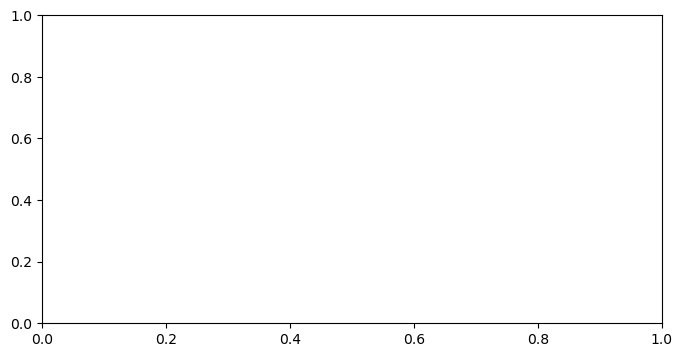

In [8]:
def get_ratio_by_mass(f):
    ref = ds_scat_arts.backscattering.swap_dims(size='mass').interp(T_grid=T, mass=ds_scat_ssrga.mass.interp(fraction=r))
    return ds_scat_ssrga.bscat.interp(temperature=T, fraction=f).pipe(lambda x: 4*np.pi*x/ref)

def get_ratio_by_dmax(f):
    ref = ds_scat_arts.backscattering.swap_dims(size='d_max').interp(T_grid=T, d_max=ds_scat_ssrga.maximum_dimension)
    return ds_scat_ssrga.bscat.interp(temperature=T, fraction=f).pipe(lambda x: 4*np.pi*x/ref)

fig, ax = plt.subplots(1,1, figsize=(8,4))
for f in [0.01, 0.1, 0.5, 1]:
    get_ratio_by_dmax(f).plot(
        x='maximum_dimension', ax=ax, label=f'f={f}', xscale='log', yscale='log'
    )
ax.legend(title=f'{habit}')
ax.set_title('Backscattering Coefficient Ratio (SSRGA / ARTS DB) at 94 GHz')

Processing habit: LargePlateAggregate
Processing habit: LargeColumnAggregate
Processing habit: LargeBlockAggregate
Processing habit: 6-BulletRosette
Processing habit: Flat3-BulletRosette
Processing habit: Perpendicular4-BulletRosette


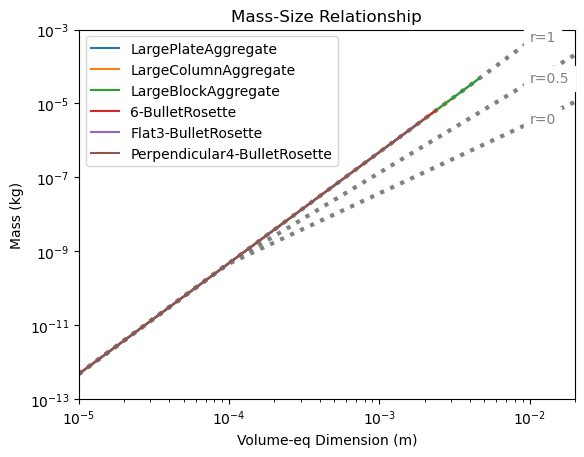

In [17]:
def mass_size_relationship(D, riming_factor):
    b = 3.0 * riming_factor + 1.9 * (1 - riming_factor)
    pivot_D = (0.0185 / 480.0) ** (1.0 / (3 - 1.9))
    pivot_mass = 480.0 * pivot_D**3
    # Invert the mass-size relationship at this size to work out "a".
    a = pivot_mass / (pivot_D**b)
    mass = np.minimum(480.0 * D**3, a * D ** b)
    return mass

def ice_fraction(D, riming_factor):
    b = 3.0 * riming_factor + 1.9 * (1 - riming_factor)
    pivot_D = (0.0185 / 480.0) ** (1.0 / (3 - 1.9))
    return np.where(D <= pivot_D, 1.0, (D/pivot_D) ** (b-3))


D = np.logspace(-5, -1, 100)
for r, color in zip([1, 0.5, 0], ['grey', 'grey', 'grey']):
    # f = ice_fraction(D, riming_factor=r)
    # f = xr.DataArray(f, coords={D.name: D}, dims=['size'])
    # plt.loglog(D, ds_scat_ssrga['mass'].interp(fraction=f), label=f'SSRGA r={r}', marker='.', linestyle='-', color=color)
    plt.loglog(D, mass_size_relationship(D, riming_factor=r), linewidth=3, linestyle=':', color=color)
    plt.text(1e-2, mass_size_relationship(1e-2, riming_factor=r), f'r={r}', color='grey', backgroundcolor='white')

for habit in [
    'LargePlateAggregate', 
    'LargeColumnAggregate', 
    'LargeBlockAggregate',

    '6-BulletRosette',
    'Flat3-BulletRosette',
    'Perpendicular4-BulletRosette',

    # '8-ColumnAggregate',
    # 'ColumnType1',
    # 'PlateType1',

    # 'EvansSnowAggregate', 
    # 'GemGraupel',
    # 'IconHail',
    # 'IconSnow', 
    # 'IconCloudIce',
    # 'LiquidSphere',

    ]:
    print(f'Processing habit: {habit}')
    ds_scat_arts_temp = scat_data.import2xarray(
        # '/scratch/patrick/Data/StandardHabits',
        '/data/s5/scattering_data/ArtsScatDbase/ArtsScatDbase_v1.0.0/StandardHabits/FullSet/',
        habit=habit, 
        interpolate_na=False,
    )
    plt.loglog(ds_scat_arts_temp['d_veq'], ds_scat_arts_temp['mass'], label=f'{habit}', linestyle='-')
# plt.plot(ds_scat_mix['mean_dimension'], ds_scat_mix['mass'], label='Habit Mixture (Ping)', c='k', linestyle='-.')

plt.title('Mass-Size Relationship')
plt.xlabel('Volume-eq Dimension (m)')
plt.ylabel('Mass (kg)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-5, 2e-2)
plt.ylim(1e-13, 1e-3)
plt.legend()
plt.show()


In [ ]:
# internal lookup table 
path = './data/scat_data_robin_shannon/'
ds = xr.open_dataset(path + 'IceCloud_3.19e+06nm_lookup.nc')
ds

<xarray.Dataset> Size: 164kB
Dimensions:                   (temperature: 5, ordinate: 20, abscissa: 60)
Coordinates:
  * temperature               (temperature) float32 20B 193.1 213.1 ... 273.1
  * ordinate                  (ordinate) float32 80B -10.0 -8.947 ... 8.947 10.0
  * abscissa                  (abscissa) float32 240B -38.38 -38.02 ... -14.9
Data variables:
    riming_factor             (ordinate) float32 80B ...
    geometric_ext_normalized  (ordinate, abscissa) float32 5kB ...
    mass_normalized           (ordinate, abscissa) float32 5kB ...
    effective_radius          (ordinate, abscissa) float32 5kB ...
    mass_flux_normalized      (ordinate, abscissa) float32 5kB ...
    ext_normalized            (temperature, ordinate, abscissa) float32 24kB ...
    bscat_ext_ratio           (temperature, ordinate, abscissa) float32 24kB ...
    single_scattering_albedo  (temperature, ordinate, abscissa) float32 24kB ...
    asymmetry_factor          (temperature, ordinate, abscissa) float32 24kB ...
    equivalent_area_radius    (temperature, ordinate, abscissa) float32 24kB ...
    doppler_velocity          (temperature, ordinate, abscissa) float32 24kB ...
Attributes:
    abscissa_type:  geometric_extinction

# test easy_arts functions

In [5]:
habit = '8-ColumnAggregate-Smooth' #'MieSpheres_H2O_liquid'

# import scattering data for the chosen habit
ds_scat = scat_data.import2xarray(
    '/scratch/li/arts-yang-liquid-simlink',
    habit=habit, 
    interpolate_na=False,
)
ds_scat['T_grid'] = ds_scat['T_grid'].assign_attrs(units='K')
ds_scat['f_grid'] = ds_scat['f_grid'].assign_attrs(units='Hz')

In [7]:
ds_scat

<xarray.Dataset> Size: 197MB
Dimensions:       (f_grid: 121, T_grid: 1, size: 47, za_sca_grid: 721,
                   za_inc_grid: 1, aa_inc_grid: 1, ext_mat_element: 1,
                   abs_vec_element: 1, aa_sca_grid: 1, pha_mat_element: 6)
Coordinates:
  * f_grid        (f_grid) float64 968B 1e+09 1.132e+09 ... 2.649e+15 3e+15
  * T_grid        (T_grid) float64 8B 293.1
    d_veq         (size) float64 376B 2e-07 3e-07 3.5e-07 ... 0.0065 0.008
    d_max         (size) float64 376B 2e-07 3e-07 3.5e-07 ... 0.0065 0.008
    mass          (size) float64 376B 4.189e-18 1.414e-17 ... 0.0002681
    d_area        (size) float64 376B 2e-07 3e-07 3.5e-07 ... 0.0065 0.008
  * za_sca_grid   (za_sca_grid) float64 6kB 0.0 0.01696 0.03416 ... 180.0 180.0
Dimensions without coordinates: size, za_inc_grid, aa_inc_grid,
                                ext_mat_element, abs_vec_element, aa_sca_grid,
                                pha_mat_element
Data variables:
    ext_mat_data  (size, f_grid, T_grid, za_inc_grid, aa_inc_grid, ext_mat_element) float64 45kB ...
    abs_vec_data  (size, f_grid, T_grid, za_inc_grid, aa_inc_grid, abs_vec_element) float64 45kB ...
    pha_mat_data  (size, f_grid, T_grid, za_sca_grid, aa_sca_grid, za_inc_grid, aa_inc_grid, pha_mat_element) float64 197MB ...
Attributes:
    description:  Spherical particle of liquid water generated using\nmiepyth...
    ptype:        PType.PTYPE_TOTAL_RND

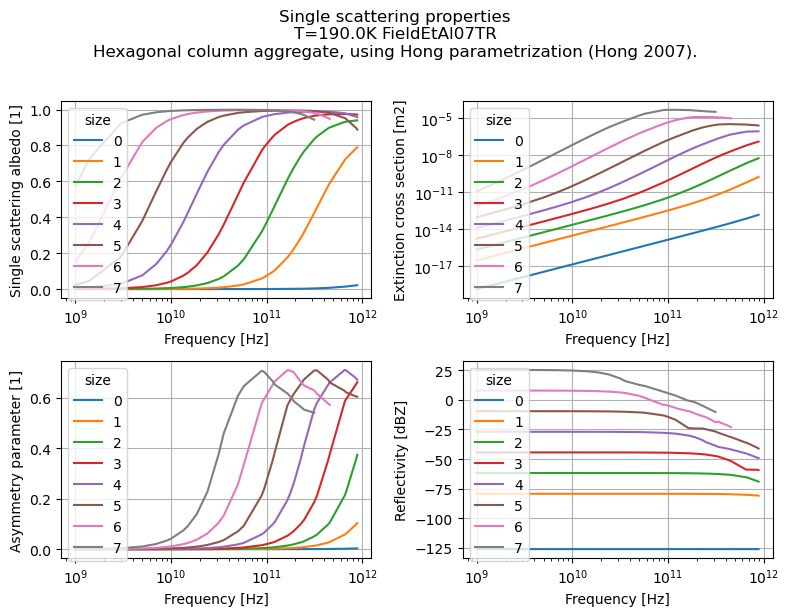

In [ ]:
ds_scat = scat_data.add_backscattering(ds_scat)
ds_scat = scat_data.add_single_scattering_albedo(ds_scat)
ds_scat = scat_data.add_asymmetry_parameter(ds_scat)

fig, ax = plt.subplots(2,2, figsize=(8,6))
kw_args = {'hue':'size', 'xscale':'log', 'add_legend':True}
ds_scat_plot = ds_scat.isel(T_grid=0, size=slice(0, None, 5))
ds_scat_plot['single_scattering_albedo'].plot(ax=ax[0,0], **kw_args)
ds_scat_plot['ext_mat_data'].rename('Extinction cross section [m2]').plot(ax=ax[0,1], **kw_args, yscale='log')
ds_scat_plot['asymmetry_parameter'].plot(ax=ax[1,0], **kw_args)
ds_scat_plot['backscattering'].pipe(
    (scat_data.backscattering2dBZ, 'backscattering'), 
    wavelength=SPEED_OF_LIGHT/ds_scat_plot['f_grid']
).rename('Reflectivity [dBZ]').plot(ax=ax[1,1], **kw_args)

for ax in ax.flatten():
    ax.grid()
    ax.set_title('')
    ax.set_xlabel('Frequency [Hz]')
fig.suptitle(f'Single scattering properties\nT={ds_scat_plot["T_grid"].data}K\n{ds_scat.attrs["description"]}', y=1.02)
fig.tight_layout()
plt.show()

# Get bulk properties with a given number density array (PND)

In [48]:
# create pnd array for a given FWC and temperature
from psd import get_psd_fwc, get_species_mass_size_info
d = ds_scat.d_max.data
a, b = get_species_mass_size_info(habit=habit, x_fit_start=1e-6)
da_psd = get_psd_fwc(
    fwc=np.atleast_1d([1e-4]), 
    t=np.atleast_1d([253]), 
    psd_size_grid=d, 
    psd_type=PSD.F07T, 
    scat_species_a=a, 
    scat_species_b=b,
 ) # units: m^-4
d_widths = np.diff(np.concatenate(([0], d))) # units: m
pnd = (da_psd * d_widths).assign_attrs(da_psd.attrs).assign_attrs(units='m-3')
pnd

<xarray.DataArray (inputs: 1, size: 48)> Size: 384B
array([[2.25095708e+04, 1.57252449e+04, 1.18596985e+04, 9.17478513e+03,
        7.19371203e+03, 5.69322255e+03, 4.54063743e+03, 3.64735393e+03,
        2.95051897e+03, 2.66484428e+03, 2.33643755e+03, 2.01552304e+03,
        1.71583267e+03, 1.44796099e+03, 1.72673497e+03, 1.39463439e+03,
        5.08684548e+02, 7.25525944e+02, 5.37752383e+02, 4.02485237e+02,
        3.71131891e+02, 2.76313818e+02, 2.19780333e+02, 2.05902159e+02,
        9.02750498e+01, 1.70430842e+02, 2.71995672e+01, 1.21047174e+02,
        1.98389925e+01, 3.69746724e+01, 1.62109542e+01, 1.94975935e+01,
        1.08271638e+01, 4.54150052e+00, 1.31509969e+00, 2.31834096e-01,
        7.24209172e-02, 8.17754377e-03, 4.96335514e-04, 3.08188312e-05,
        3.56454076e-05, 5.55906779e-06, 6.92121683e-07, 3.70354881e-08,
        8.12644014e-10, 2.84593080e-12, 8.85557126e-17, 3.56628431e-21]])
Coordinates:
    fwc          (inputs) float64 8B 0.0001
    temperature  (inputs) int64 8B 253
    d_max        (size) float64 384B 1.623e-05 3.246e-05 ... 0.01882 0.02286
Dimensions without coordinates: inputs, size
Attributes:
    psd_type:  FieldEtAl07TR
    a:         0.5088158275055679
    b:         2.405775313011149
    units:     m-3

In [49]:
# calculate bulk scattering properties
ds_bulk_scat = scat_data.bulk_scattering_property(ds_scat, pnd.T)
ds_bulk_scat = scat_data.interp_freq_temp(ds_bulk_scat, freq=None, temp=da_psd.temperature)
ds_bulk_scat = ds_bulk_scat.assign_attrs(da_psd.attrs) # copy attributes for plotting title
ds_bulk_scat

<xarray.Dataset> Size: 2kB
Dimensions:                   (f_grid: 34, inputs: 1, za_inc_grid: 1,
                               aa_inc_grid: 1, ext_mat_element: 1,
                               abs_vec_element: 1, aa_sca_grid: 1)
Coordinates:
  * f_grid                    (f_grid) float64 272B 1e+09 1.4e+09 ... 8.864e+11
    fwc                       (inputs) float64 8B 0.0001
    temperature               (inputs) int64 8B 253
    T_grid                    (inputs) int64 8B 253
Dimensions without coordinates: inputs, za_inc_grid, aa_inc_grid,
                                ext_mat_element, abs_vec_element, aa_sca_grid
Data variables:
    ext_mat_data              (f_grid, inputs, za_inc_grid, aa_inc_grid, ext_mat_element) float64 272B ...
    abs_vec_data              (f_grid, inputs, za_inc_grid, aa_inc_grid, abs_vec_element) float64 272B ...
    backscattering            (f_grid, inputs, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 272B ...
    single_scattering_albedo  (f_grid, inputs, za_inc_grid, aa_inc_grid, ext_mat_element, abs_vec_element) float64 272B ...
    asymmetry_parameter       (f_grid, inputs, aa_sca_grid, za_inc_grid, aa_inc_grid, ext_mat_element, abs_vec_element) float64 272B ...
Attributes:
    description:  Habit mix: 'ThickPlate' (id 15) and 'LargePlateAggregate' (...
    ptype:        PType.PTYPE_TOTAL_RND
    psd_type:     FieldEtAl07TR
    a:            0.5088158275055679
    b:            2.405775313011149

### Recreate Geer et al. (2021) Figure 1

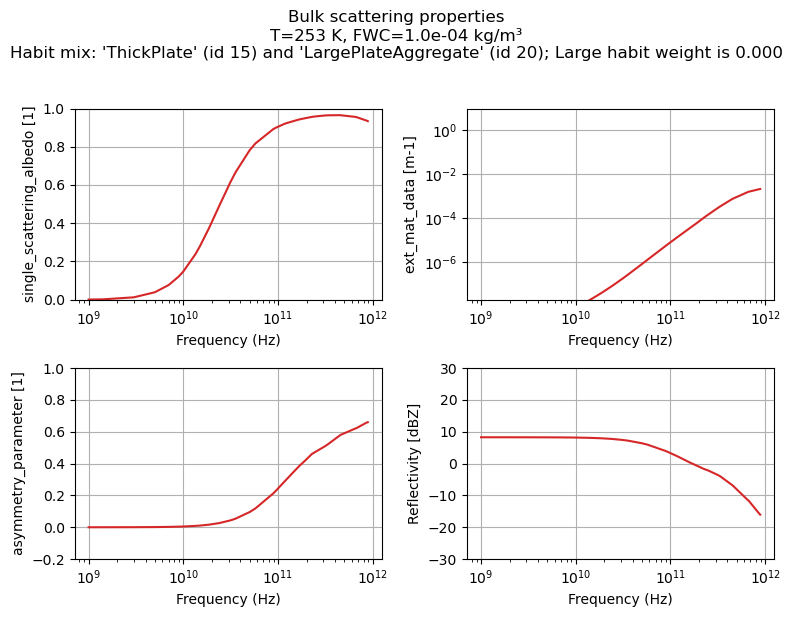

In [50]:
fig, ax = plt.subplots(2,2, figsize=(8,6))
kw_args = {'x':'f_grid', 'xscale':'log', 'color':'C3'}
ds_bulk_scat['single_scattering_albedo'].plot(ax=ax[0,0], **kw_args)
ds_bulk_scat['ext_mat_data'].plot(ax=ax[0,1], **kw_args, yscale='log')
ds_bulk_scat['asymmetry_parameter'].plot(ax=ax[1,0], **kw_args)
ds_bulk_scat['backscattering'].pipe(
    (scat_data.backscattering2dBZ, 'backscattering'), 
    wavelength=SPEED_OF_LIGHT/ds_bulk_scat['f_grid']
).rename('Reflectivity [dBZ]').plot(ax=ax[1,1], **kw_args)

ax[0,0].set_ylim(0,1)
ax[0,1].set_ylim(2e-8, 1e1)
ax[1,0].set_ylim(-0.2,1)
ax[1,1].set_ylim(-30,30)

for ax in ax.flatten():
    ax.grid()
    ax.set_title('')
    ax.set_xlabel('Frequency (Hz)')

fig.suptitle(f'Bulk scattering properties\nT={ds_bulk_scat.temperature.data[0]} K, FWC={ds_bulk_scat.fwc.data[0]:.1e} kg/m³\n{ds_bulk_scat.attrs.get("description", "")}', y=1.02)
fig.tight_layout()
plt.show()

### Recreate Geer et al. (2021) Figure 2

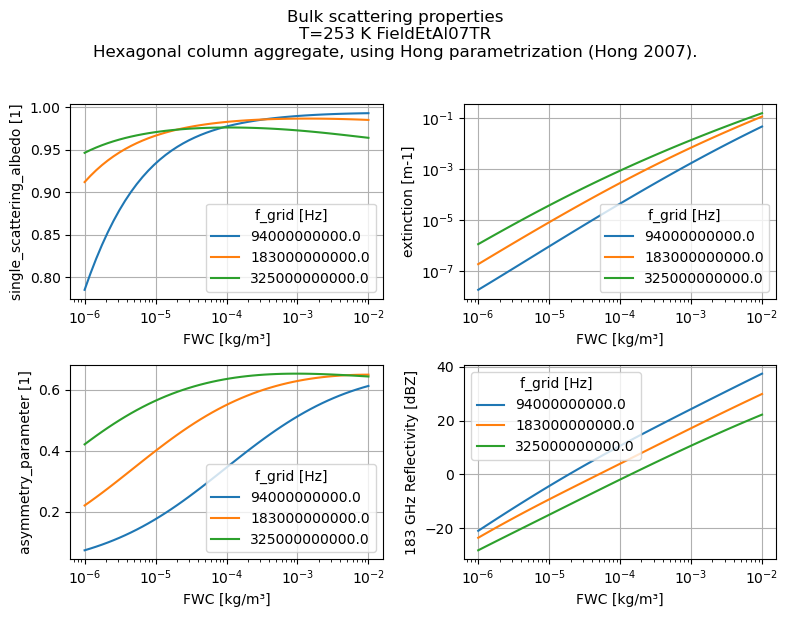

In [ ]:
# make a 2D PND array for varying FWC
d = ds_scat.d_max.data
a, b = get_species_mass_size_info(habit=Habit.Plate, x_fit_start=100e-6)

da_psd = get_psd_fwc(
    fwc=np.logspace(-6, -2, 50), 
    t=253*np.ones(50), 
    psd_size_grid=d, 
    psd_type=PSD.F07T, 
    scat_species_a=a, 
    scat_species_b=b,
    ) # units: m^-4
d_widths = np.diff(np.concatenate(([0], d))) # units: m
pnd = da_psd * d_widths # units: m^-1

# bulk scattering properties for varying FWC at fixed frequency and temperature
ds_bulk_scat_plot = scat_data.bulk_scattering_property(
    ds_scat.pipe(scat_data.interp_freq_temp, freq=[94e9,183e9,325e9], temp=253), 
    pnd.T,
    )

# plot 
fig, ax = plt.subplots(2,2, figsize=(8,6))
kw_args = {'x':'fwc', 'xscale':'log', 'hue':'f_grid', 'add_legend':True}
ds_bulk_scat_plot['single_scattering_albedo'].plot(ax=ax[0,0], **kw_args)
ds_bulk_scat_plot['ext_mat_data'].rename('extinction').plot(ax=ax[0,1], **kw_args, yscale='log')
ds_bulk_scat_plot['asymmetry_parameter'].plot(ax=ax[1,0], **kw_args)
ds_bulk_scat_plot['backscattering'].pipe(
    (scat_data.backscattering2dBZ, 'backscattering'), 
    wavelength=SPEED_OF_LIGHT/ds_bulk_scat_plot['f_grid']
).rename('Reflectivity [dBZ]').plot(ax=ax[1,1], **kw_args)

for ax in ax.flatten():
    ax.grid()
    ax.set_title('')
    ax.set_xlabel('FWC [kg/m³]')

fig.suptitle(f'Bulk scattering properties\nT=253 K {PSD.F07T}\n{ds_bulk_scat_plot.attrs.get("description", "")}', y=1.02)
fig.tight_layout()
plt.show()

# Testing helper function interp_freq_temp 
interpretation / extrapolation on frequency and/or temperature grids

In [73]:
# one frequency outside of range should give an error message
scat_data.interp_freq_temp(ds_scat, freq=[8e14], temp=None)

ValueError: Requested frequency outside data range 1000000000.0 - 886400000000.0 Hz.

In [74]:
# extrapolation in temperature dimension
scat_data.interp_freq_temp(ds_scat, freq=[94e9, 8e10], temp=280)

<xarray.Dataset> Size: 3MB
Dimensions:                   (size: 48, za_sca_grid: 721, f_grid: 2,
                               za_inc_grid: 1, aa_inc_grid: 1,
                               ext_mat_element: 1, abs_vec_element: 1,
                               aa_sca_grid: 1, pha_mat_element: 6)
Coordinates:
    d_veq                     (size) float64 384B 1e-05 2e-05 ... 0.004563
    d_max                     (size) float64 384B 1.623e-05 ... 0.02286
    mass                      (size) float64 384B 4.8e-13 3.84e-12 ... 4.56e-05
    d_area                    (size) float64 384B 1.44e-05 2.88e-05 ... 0.01399
  * za_sca_grid               (za_sca_grid) float64 6kB 0.0 0.25 ... 179.8 180.0
  * f_grid                    (f_grid) float64 16B 9.4e+10 8e+10
    T_grid                    int64 8B 280
Dimensions without coordinates: size, za_inc_grid, aa_inc_grid,
                                ext_mat_element, abs_vec_element, aa_sca_grid,
                                pha_mat_element
Data variables:
    ext_mat_data              (size, f_grid, za_inc_grid, aa_inc_grid, ext_mat_element) float64 768B ...
    abs_vec_data              (size, f_grid, za_inc_grid, aa_inc_grid, abs_vec_element) float64 768B ...
    pha_mat_data              (size, f_grid, za_sca_grid, aa_sca_grid, za_inc_grid, aa_inc_grid, pha_mat_element) float64 3MB ...
    backscattering            (size, f_grid, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 768B ...
    single_scattering_albedo  (size, f_grid, za_inc_grid, aa_inc_grid) float64 768B ...
    asymmetry_parameter       (size, f_grid, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 768B ...
Attributes:
    description:  Habit mix: 'ThickPlate' (id 15) and 'LargePlateAggregate' (...
    ptype:        PType.PTYPE_TOTAL_RND

In [75]:
# only interpolate temperature without frequency 
scat_data.interp_freq_temp(ds_scat, freq=None, temp=200)

<xarray.Dataset> Size: 57MB
Dimensions:                   (f_grid: 34, size: 48, za_sca_grid: 721,
                               za_inc_grid: 1, aa_inc_grid: 1,
                               ext_mat_element: 1, abs_vec_element: 1,
                               aa_sca_grid: 1, pha_mat_element: 6)
Coordinates:
  * f_grid                    (f_grid) float64 272B 1e+09 1.4e+09 ... 8.864e+11
    d_veq                     (size) float64 384B 1e-05 2e-05 ... 0.004563
    d_max                     (size) float64 384B 1.623e-05 ... 0.02286
    mass                      (size) float64 384B 4.8e-13 3.84e-12 ... 4.56e-05
    d_area                    (size) float64 384B 1.44e-05 2.88e-05 ... 0.01399
  * za_sca_grid               (za_sca_grid) float64 6kB 0.0 0.25 ... 179.8 180.0
    T_grid                    int64 8B 200
Dimensions without coordinates: size, za_inc_grid, aa_inc_grid,
                                ext_mat_element, abs_vec_element, aa_sca_grid,
                                pha_mat_element
Data variables:
    ext_mat_data              (size, f_grid, za_inc_grid, aa_inc_grid, ext_mat_element) float64 13kB ...
    abs_vec_data              (size, f_grid, za_inc_grid, aa_inc_grid, abs_vec_element) float64 13kB ...
    pha_mat_data              (size, f_grid, za_sca_grid, aa_sca_grid, za_inc_grid, aa_inc_grid, pha_mat_element) float64 56MB ...
    backscattering            (size, f_grid, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 13kB ...
    single_scattering_albedo  (size, f_grid, za_inc_grid, aa_inc_grid) float64 13kB ...
    asymmetry_parameter       (size, f_grid, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 13kB ...
Attributes:
    description:  Habit mix: 'ThickPlate' (id 15) and 'LargePlateAggregate' (...
    ptype:        PType.PTYPE_TOTAL_RND

In [76]:
# point-wise interpolation (i.e. specific frequency and temperature value pair)
# Note: very slow!! (a few minutes for 2 points)
target_freq = xr.DataArray([94e9, 94e9], dims='point')
target_temp = xr.DataArray([200, 280], dims='point')
scat_data.interp_freq_temp(ds_scat, freq=target_freq, temp=target_temp)

<xarray.Dataset> Size: 3MB
Dimensions:                   (size: 48, za_sca_grid: 721, point: 2,
                               za_inc_grid: 1, aa_inc_grid: 1,
                               ext_mat_element: 1, abs_vec_element: 1,
                               aa_sca_grid: 1, pha_mat_element: 6)
Coordinates:
    d_veq                     (size) float64 384B 1e-05 2e-05 ... 0.004563
    d_max                     (size) float64 384B 1.623e-05 ... 0.02286
    mass                      (size) float64 384B 4.8e-13 3.84e-12 ... 4.56e-05
    d_area                    (size) float64 384B 1.44e-05 2.88e-05 ... 0.01399
  * za_sca_grid               (za_sca_grid) float64 6kB 0.0 0.25 ... 179.8 180.0
    f_grid                    (point) float64 16B 9.4e+10 9.4e+10
    T_grid                    (point) int64 16B 200 280
Dimensions without coordinates: size, point, za_inc_grid, aa_inc_grid,
                                ext_mat_element, abs_vec_element, aa_sca_grid,
                                pha_mat_element
Data variables:
    ext_mat_data              (size, point, za_inc_grid, aa_inc_grid, ext_mat_element) float64 768B ...
    abs_vec_data              (size, point, za_inc_grid, aa_inc_grid, abs_vec_element) float64 768B ...
    pha_mat_data              (size, point, za_sca_grid, aa_sca_grid, za_inc_grid, aa_inc_grid, pha_mat_element) float64 3MB ...
    backscattering            (size, point, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 768B ...
    single_scattering_albedo  (size, point, za_inc_grid, aa_inc_grid) float64 768B ...
    asymmetry_parameter       (size, point, aa_sca_grid, za_inc_grid, aa_inc_grid) float64 768B ...
Attributes:
    description:  Habit mix: 'ThickPlate' (id 15) and 'LargePlateAggregate' (...
    ptype:        PType.PTYPE_TOTAL_RND